# Statistical Significance of the Results Tables

For each dataset, tests whether the **best** method's win over the **runner-up**
is statistically significant, using a two-sided Wilcoxon signed-rank test on the
60 paired per-run macro-F1 differences (each record = one subsample evaluated by
all four methods, so pairs are exact).

Outputs:
1. A per-dataset table: best, runner-up, mean paired difference, p-value, significance at p<0.05.
2. The dagger list for the paper tables (mark the bold entry when its win is significant).
3. The outcome-summary counts: of our 18 wins, how many are significant (X), plus significant losses.
4. A forest plot: paired mean difference (ours - strongest baseline) with 95% CI per dataset,
   grouped by modality, zero line for reference -> `figures_analysis/fig_significance_forest.png`.
5. `significance_results_v1.json` with all numbers for the paper edit.

In [1]:
# Colab: mount Drive and cd to the repo root (safe to run anywhere)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/prediction-only-expert-identification
except ImportError:
    pass

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_578/2929867486.py", line 5, in <cell line: 0>
    get_ipython().run_line_magic('cd', '/content/drive/MyDrive/prediction-only-expert-identification')
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py", line 2418, in run_line_magic
    result = fn(*args, **kwargs)
  File "<decorator-gen-85>", line 2, in cd
  File "/usr/local/lib/python3.13/dist-packages/IPython/core/magic.py", line 187, in <lambda>
    call = lambda f, *a, **k: f(*a, **k)
                        

In [2]:
import os
# Anchor to repo root so relative data/ paths resolve no matter where this runs.
while not os.path.isdir("data/results") and os.getcwd() != "/":
    os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: /content/drive/MyDrive/prediction-only-expert-identification


In [3]:
import json
import numpy as np
from collections import defaultdict
from scipy import stats

RESULTS_JSONL = "data/results/experiment_records.jsonl"
OUT_JSON = "significance_results_v1.json"
ALPHA = 0.05

METHODS = {
    "experts_weighted": "Experts (W)",
    "all_majority":     "All (Maj)",
    "em":               "EM",
    "sml":              "SML",
}
OURS = "experts_weighted"

DATASETS = {
    "CIFAR10":      ("vision", "CIFAR-10"),
    "CIFAR100":     ("vision", "CIFAR-100"),
    "SVHN":         ("vision", "SVHN"),
    "ImageWoof-49": ("vision", "ImageWoof"),
    "Food-101":     ("vision", "Food-101"),
    "Oxford-IIIT Pet (Binary: Cats vs Dogs)": ("vision", "Oxford Pets"),
    "PCAM":         ("vision", "PCam"),
    "Kuzushiji-49": ("vision", "Kuzushiji-49"),
    "sklearn_covertype": ("tabular", "Covertype"),
    "HEPMASS":           ("tabular", "HepMass"),
    "HIGGS":             ("tabular", "HIGGS"),
    "Santander_Customer_Transaction_Prediction": ("tabular", "Santander CT"),
    "Satellite Image":   ("tabular", "Satellite Image"),
    "uci_letter":        ("tabular", "UCI Letter"),
    "UCI_Pendigits":     ("tabular", "UCI Pendigits"),
    "Banknote_Authentication": ("tabular", "Banknote Auth."),
    "20Newsgroups":    ("text", "20 NG"),
    "Amazon_Polarity": ("text", "Amazon Pol."),
    "CoLA":            ("text", "CoLA"),
    "IMDb":            ("text", "IMDb"),
    "MultiNLI":        ("text", "MultiNLI"),
    "QNLI":            ("text", "QNLI"),
    "SST2":            ("text", "SST-2"),
    "DBpedia":         ("text", "DBpedia"),
}
# NOTE: if any raw name above mismatches your records, the check cell below will list it -
# copy the exact keys from results_tables.ipynb's DATASETS dict (source of truth).

# dataset -> list of per-record dicts {method: f1}, preserving pairing within a record
runs = defaultdict(list)
with open(RESULTS_JSONL) as f:
    for line in f:
        rec = json.loads(line)
        mf = rec.get("macro_f1", {})
        if isinstance(mf, dict) and all(k in mf and mf[k] is not None for k in METHODS):
            runs[rec["dataset"]].append({k: float(mf[k]) for k in METHODS})

print(f"datasets with complete records: {len(runs)}")
for ds, r in sorted(runs.items()):
    if len(r) != 60:
        print(f"  WARNING {ds}: {len(r)} records (expected 60)")
unmapped = sorted(set(runs) - set(DATASETS))
if unmapped:
    print("WARNING: records with no DATASETS mapping (fix DATASETS above):", unmapped)
missing = sorted(set(DATASETS) - set(runs))
if missing:
    print("WARNING: mapped datasets with no records:", missing)

datasets with complete records: 24


## Per-dataset test: best vs runner-up

Two-sided Wilcoxon signed-rank on the paired per-run differences. `zero_method="zsplit"`
keeps zero differences informative. Also computes ours - strongest-baseline differences
and a t-based 95% CI for the forest plot.

In [4]:
results = []
for raw, (modality, pretty) in DATASETS.items():
    if raw not in runs:
        continue
    R = runs[raw]
    arr = {k: np.array([r[k] for r in R]) for k in METHODS}
    means = {k: float(a.mean()) for k, a in arr.items()}
    order = sorted(means, key=means.get, reverse=True)
    best, runner = order[0], order[1]

    d_best = arr[best] - arr[runner]
    if np.allclose(d_best, 0):
        p_best = 1.0
    else:
        p_best = float(stats.wilcoxon(d_best, zero_method="zsplit",
                                      alternative="two-sided").pvalue)

    # ours vs strongest baseline (for forest plot + narrative)
    base_means = {k: v for k, v in means.items() if k != OURS}
    strongest = max(base_means, key=base_means.get)
    d_ours = arr[OURS] - arr[strongest]
    n = len(d_ours)
    mean_d = float(d_ours.mean())
    se = float(d_ours.std(ddof=1) / np.sqrt(n))
    tcrit = float(stats.t.ppf(0.975, n - 1))
    ci = (mean_d - tcrit * se, mean_d + tcrit * se)
    if np.allclose(d_ours, 0):
        p_ours = 1.0
    else:
        p_ours = float(stats.wilcoxon(d_ours, zero_method="zsplit",
                                      alternative="two-sided").pvalue)

    results.append({
        "dataset": pretty, "modality": modality, "n_runs": n,
        "best": METHODS[best], "runner_up": METHODS[runner],
        "best_is_ours": best == OURS,
        "mean_diff_best_vs_runner": float(d_best.mean()),
        "p_best_vs_runner": p_best,
        "significant": bool(p_best < ALPHA),
        "strongest_baseline": METHODS[strongest],
        "mean_diff_ours_vs_strongest": mean_d,
        "ci95_ours_vs_strongest": [float(ci[0]), float(ci[1])],
        "p_ours_vs_strongest": p_ours,
    })

hdr = f"{'dataset':<16}{'best':<13}{'runner-up':<13}{'mean diff':>10}{'p':>10}  sig"
print(hdr); print("-" * len(hdr))
for r in results:
    print(f"{r['dataset']:<16}{r['best']:<13}{r['runner_up']:<13}"
          f"{r['mean_diff_best_vs_runner']:>10.4f}{r['p_best_vs_runner']:>10.2e}"
          f"  {'YES' if r['significant'] else 'no'}{'  <- ours' if r['best_is_ours'] else ''}")

dataset         best         runner-up     mean diff         p  sig
-------------------------------------------------------------------
CIFAR-10        Experts (W)  EM               0.0312  1.63e-11  YES  <- ours
CIFAR-100       Experts (W)  SML              0.0305  1.63e-11  YES  <- ours
SVHN            Experts (W)  EM               0.0332  1.63e-11  YES  <- ours
ImageWoof       Experts (W)  SML              0.0166  1.63e-11  YES  <- ours
Food-101        Experts (W)  SML              0.0138  1.90e-11  YES  <- ours
Oxford Pets     Experts (W)  All (Maj)        0.0093  2.60e-03  YES  <- ours
PCam            EM           All (Maj)        0.0031  1.15e-03  YES
Kuzushiji-49    Experts (W)  SML              0.0254  1.63e-11  YES  <- ours
Covertype       Experts (W)  All (Maj)        0.0576  1.63e-11  YES  <- ours
HepMass         Experts (W)  SML              0.2920  1.63e-11  YES  <- ours
HIGGS           All (Maj)    SML              0.0001  9.97e-01  no
Santander CT    SML          EM     

## Paper numbers: dagger list and outcome-summary counts

In [5]:
our_wins        = [r for r in results if r["best_is_ours"]]
our_sig_wins    = [r for r in results if r["best_is_ours"] and r["significant"]]
losses          = [r for r in results if not r["best_is_ours"]]
sig_losses      = [r for r in results if not r["best_is_ours"] and r["significant"]]

print(f"our wins: {len(our_wins)} / {len(results)}")
print(f"significant wins (X for the outcome summary): {len(our_sig_wins)}")
print("  dagger these bold entries:", [r["dataset"] for r in our_sig_wins])
print(f"losses: {len(losses)}: {[r['dataset'] for r in losses]}")
print(f"  of which the winner's lead is significant: {[r['dataset'] for r in sig_losses]}")
print(f"  ties in effect (winner not significant): "
      f"{[r['dataset'] for r in losses if not r['significant']]}")

with open(OUT_JSON, "w") as f:
    json.dump({"alpha": ALPHA, "test": "two-sided Wilcoxon signed-rank, paired per-run",
               "results": results}, f, indent=1)
print("\nsaved", OUT_JSON)

our wins: 16 / 20
significant wins (X for the outcome summary): 16
  dagger these bold entries: ['CIFAR-10', 'CIFAR-100', 'SVHN', 'ImageWoof', 'Food-101', 'Oxford Pets', 'Kuzushiji-49', 'Covertype', 'HepMass', 'Satellite Image', 'UCI Letter', 'UCI Pendigits', 'CoLA', 'MultiNLI', 'SST-2', 'DBpedia']
losses: 4: ['PCam', 'HIGGS', 'Santander CT', 'QNLI']
  of which the winner's lead is significant: ['PCam', 'Santander CT', 'QNLI']
  ties in effect (winner not significant): ['HIGGS']

saved significance_results_v1.json


## Forest plot: ours - strongest baseline, 95% CI per dataset

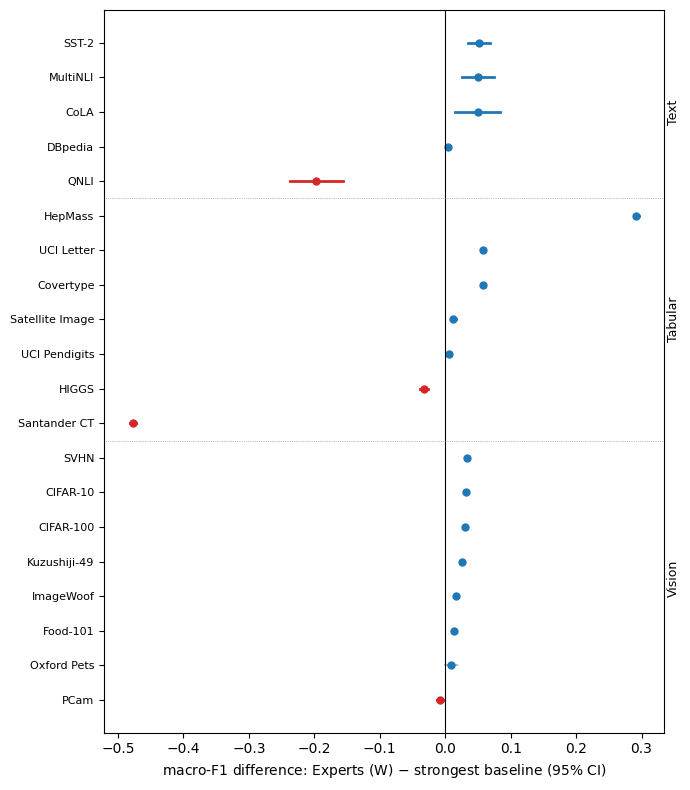

In [6]:
import matplotlib.pyplot as plt

os.makedirs("figures_analysis", exist_ok=True)
by_mod = {"vision": [], "tabular": [], "text": []}
for r in results:
    by_mod[r["modality"]].append(r)

rows, labels, seps = [], [], []
for mod in ["vision", "tabular", "text"]:
    for r in sorted(by_mod[mod], key=lambda r: r["mean_diff_ours_vs_strongest"]):
        rows.append(r); labels.append(r["dataset"])
    seps.append(len(rows) - 0.5)

fig, ax = plt.subplots(figsize=(7.0, 8.0))
for i, r in enumerate(rows):
    lo, hi = r["ci95_ours_vs_strongest"]
    sig = not (lo <= 0 <= hi)
    color = "tab:blue" if r["mean_diff_ours_vs_strongest"] > 0 else "tab:red"
    ax.plot([lo, hi], [i, i], color=color, lw=2 if sig else 1.2,
            alpha=1.0 if sig else 0.55)
    ax.plot(r["mean_diff_ours_vs_strongest"], i, "o", color=color, ms=5)
ax.axvline(0, color="black", lw=0.8)
for s in seps[:-1]:
    ax.axhline(s, color="gray", lw=0.5, ls=":")
ax.set_yticks(range(len(rows))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("macro-F1 difference: Experts (W) $-$ strongest baseline (95% CI)")
mid = lambda lst: (lst[0] + lst[1]) / 2
bounds = [-0.5] + seps
for name, y0, y1 in zip(["Vision", "Tabular", "Text"], bounds[:-1], bounds[1:]):
    ax.text(1.005, mid([y0, y1]), name, transform=ax.get_yaxis_transform(),
            rotation=90, va="center", fontsize=9)
fig.tight_layout()
fig.savefig("figures_analysis/fig_significance_forest.png", dpi=300, bbox_inches="tight")
plt.show()

## Robustness checks

Four checks on the headline result:
1. **Win-run counts** - in how many of the 60 runs the best method beats the runner-up (makes the consistency mechanism visible).
2. **Stricter verdicts** - alpha = 0.01, and Holm-Bonferroni correction across all 24 tests.
3. **Size-dependence** - Spearman correlation of the paired difference with test size; flags datasets where the advantage direction depends on test size (would undermine pooling).
4. **The +-std-overlap criterion** (Irad's original suggestion) - counts wins whose mean+-std does not overlap the runner-up's.

In [7]:
ALPHA_STRICT = 0.01

# Recollect per-run structures with test-size info for the size check
runs_full = defaultdict(list)
with open(RESULTS_JSONL) as f:
    for line in f:
        rec = json.loads(line)
        mf = rec.get("macro_f1", {})
        if isinstance(mf, dict) and all(k in mf and mf[k] is not None for k in METHODS):
            entry = {k: float(mf[k]) for k in METHODS}
            entry["_size"] = rec.get("test_size", rec.get("n_test",
                             rec.get("subset_size", None)))
            runs_full[rec["dataset"]].append(entry)

size_field_ok = all(any(e["_size"] is not None for e in v) for v in runs_full.values())
if not size_field_ok:
    print("NOTE: no test-size field found in records under names "
          "test_size / n_test / subset_size - size check will be skipped; "
          "tell me the field name and I'll adjust.")

# Holm-Bonferroni over the 24 best-vs-runner-up p-values
ps = [(r["dataset"], r["p_best_vs_runner"]) for r in results]
m = len(ps)
holm_sig = {}
for rank, (ds, p) in enumerate(sorted(ps, key=lambda t: t[1])):
    threshold = ALPHA / (m - rank)
    if p < threshold and all(holm_sig.get(d, True) for d, _ in sorted(ps, key=lambda t: t[1])[:rank]):
        holm_sig[ds] = True
    else:
        holm_sig[ds] = False
# standard Holm: reject in order until first failure
holm_sig = {}
rejected = True
for rank, (ds, p) in enumerate(sorted(ps, key=lambda t: t[1])):
    if rejected and p < ALPHA / (m - rank):
        holm_sig[ds] = True
    else:
        rejected = False
        holm_sig[ds] = False

hdr = (f"{'dataset':<16}{'best':<13}{'wins/60':>8}{'p':>10}"
       f"{'a=.05':>7}{'a=.01':>7}{'Holm':>6}{'size-rho':>9}{'std-sep':>8}")
print(hdr); print("-" * len(hdr))
summary = {"std_sep_wins": 0, "a01_wins": 0, "holm_wins": 0, "size_flags": []}
for r in results:
    raw = next(k for k, (mo, p) in DATASETS.items() if p == r["dataset"])
    R = runs_full[raw]
    arr = {k: np.array([e[k] for e in R]) for k in METHODS}
    best_k = next(k for k, lab in METHODS.items() if lab == r["best"])
    run_k  = next(k for k, lab in METHODS.items() if lab == r["runner_up"])
    d = arr[best_k] - arr[run_k]
    wins = int((d > 0).sum())

    a05 = r["p_best_vs_runner"] < 0.05
    a01 = r["p_best_vs_runner"] < ALPHA_STRICT
    hol = holm_sig[r["dataset"]]

    rho_s = "-"
    sizes = np.array([e["_size"] for e in R], dtype=float) if size_field_ok else None
    if size_field_ok and sizes is not None and np.isfinite(sizes).all():
        rho, rho_p = stats.spearmanr(sizes, d)
        rho_s = f"{rho:+.2f}"
        # flag: significant size dependence AND the difference changes sign across size halves
        lo_half = d[sizes <= np.median(sizes)].mean()
        hi_half = d[sizes > np.median(sizes)].mean()
        if rho_p < 0.05 and np.sign(lo_half) != np.sign(hi_half):
            summary["size_flags"].append(r["dataset"])

    # Irad's +-std overlap criterion
    mb, sb = arr[best_k].mean(), arr[best_k].std()
    mr, sr = arr[run_k].mean(), arr[run_k].std()
    std_sep = (mb - sb) > (mr + sr)

    if r["best_is_ours"]:
        summary["std_sep_wins"] += int(std_sep)
        summary["a01_wins"] += int(a01)
        summary["holm_wins"] += int(hol)

    print(f"{r['dataset']:<16}{r['best']:<13}{wins:>8}{r['p_best_vs_runner']:>10.1e}"
          f"{'Y' if a05 else '-':>7}{'Y' if a01 else '-':>7}{'Y' if hol else '-':>6}"
          f"{rho_s:>9}{'Y' if std_sep else '-':>8}"
          f"{'  <- ours' if r['best_is_ours'] else ''}")

print()
print(f"of our 18 wins: significant at a=0.01: {summary['a01_wins']}; "
      f"after Holm correction (a=0.05 family): {summary['holm_wins']}; "
      f"separated under +-std overlap: {summary['std_sep_wins']}")
print(f"size-dependence flags (sign flips with test size): "
      f"{summary['size_flags'] or 'none'}")

# ours-vs-strongest for the six losses, printed for the paper narrative
print()
print("ours vs strongest baseline on the loss datasets:")
for r in results:
    if not r["best_is_ours"]:
        lo, hi = r["ci95_ours_vs_strongest"]
        print(f"  {r['dataset']:<16} mean {r['mean_diff_ours_vs_strongest']:+.4f}  "
              f"CI [{lo:+.4f}, {hi:+.4f}]  p={r['p_ours_vs_strongest']:.2e}")


NOTE: no test-size field found in records under names test_size / n_test / subset_size - size check will be skipped; tell me the field name and I'll adjust.
dataset         best          wins/60         p  a=.05  a=.01  Holm size-rho std-sep
------------------------------------------------------------------------------------
CIFAR-10        Experts (W)        60   1.6e-11      Y      Y     Y        -       Y  <- ours
CIFAR-100       Experts (W)        60   1.6e-11      Y      Y     Y        -       Y  <- ours
SVHN            Experts (W)        60   1.6e-11      Y      Y     Y        -       Y  <- ours
ImageWoof       Experts (W)        60   1.6e-11      Y      Y     Y        -       Y  <- ours
Food-101        Experts (W)        59   1.9e-11      Y      Y     Y        -       Y  <- ours
Oxford Pets     Experts (W)        45   2.6e-03      Y      Y     Y        -       -  <- ours
PCam            EM                 39   1.1e-03      Y      Y     Y        -       -
Kuzushiji-49    Experts 